# The Conditional Term Structure of Risk Premia

This notebook demonstrates the **conditional** version of the model from ["Macro Strikes Back: The Term Structure of Risk Premia"](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4752696) (Bryzgalova, Huang, and Julliard, 2024). It is the time-varying counterpart of `RiskPremiaTermStructure` in `examples/msb_replication.ipynb`.

The conditional model adds a VAR(`q`) layer on the latent factors $v_t$ (optionally augmented with external predictors $z_t$). The factor $g_t$ now loads on the VAR innovations $\varepsilon_{v,t}$ rather than on $v_t$ itself, and the term structure of risk premia $\lambda^S_{g,t-1}$ becomes time-varying, indexed by both horizon $S$ and conditioning time $t-1$. See Section 2.2 / Proposition A2 of the paper.

We use the same FF275 + GDP dataset as the unconditional notebook. GDP is used both as the macro factor whose risk premia we want to estimate and as the external predictor $z_t$ that helps forecast the latent factors.

In [1]:
from empfin import ConditionalRiskPremiaTermStructure, msb_replication

data_df = msb_replication()
gdp = data_df.pop("GDP")

Estimation runs automatically when the class is instantiated. With 2000 draws plus 2000 burn-in iterations, expect a runtime of a few minutes on the FF275 + GDP sample. Setting `predictors=gdp.to_frame()` includes GDP as an external predictor in the VAR; pass `predictors=None` to fit the VAR on latent factors only.

In [2]:
crpts = ConditionalRiskPremiaTermStructure(
    assets=data_df,
    factor=gdp,
    s_bar=12,
    n_draws=2000,
    burnin=2000,
    k=5,
    predictors=gdp.to_frame(),
    q=1,
)

100%|██████████| 4000/4000 [03:15<00:00, 20.46it/s]


`plot_premia_time_series` plots the time-varying risk premium for selected horizons (this replicates Figure 8 of the paper). Each subplot shows the posterior median of $\lambda^S_{g,t}$ over time with a credible interval. With quarterly data, $S=0$, $S=4$, $S=8$, $S=12$ correspond to 1 quarter, 1 year, 2 years, and 3 years.

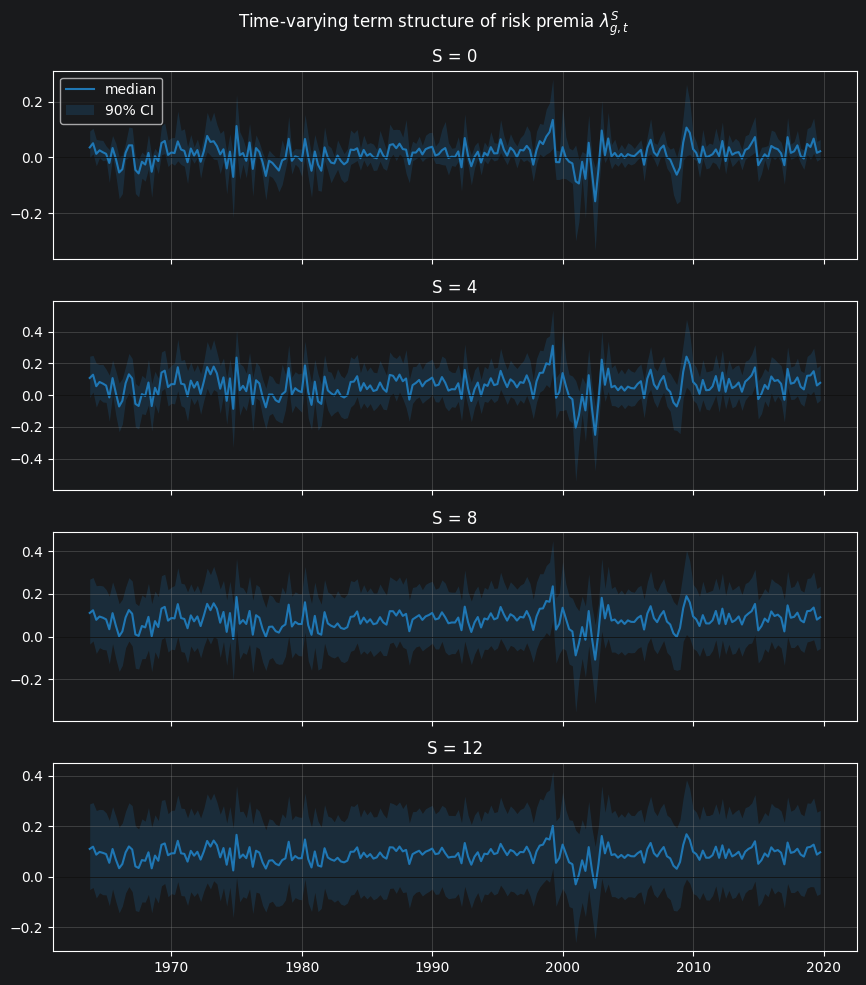

In [3]:
crpts.plot_premia_time_series(horizons=(0, 4, 8, 12))

We can also inspect the term structure of risk premia at a specific conditioning date. By default `plot_premia_term_structure` uses the latest available date.

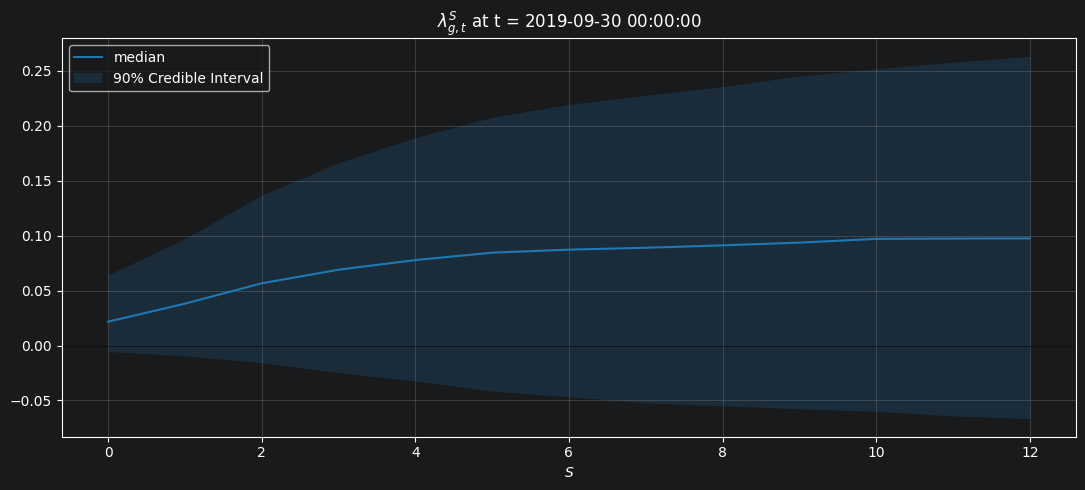

In [4]:
crpts.plot_premia_term_structure()

Median factor loadings (one row per asset, one column per latent factor).

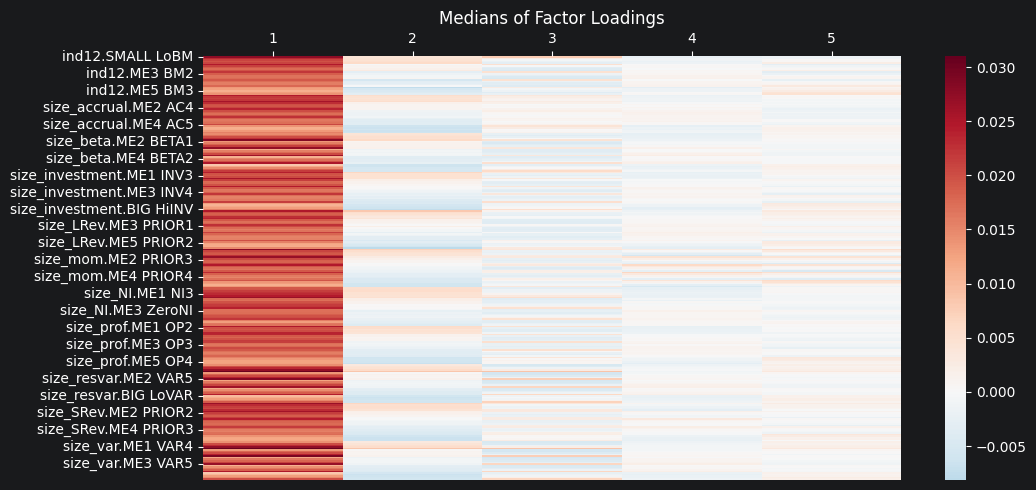

In [5]:
crpts.plot_loadings_heatmap()

We can also compute the time-averaged factor mimicking portfolio for a given horizon.

In [8]:
w_fm = crpts.factor_mimicking_portfolio(S=4)
w_fm.median()

ind12.SMALL LoBM      0.028530
ind12.ME1 BM2         0.021265
ind12.ME1 BM3         0.064789
ind12.ME1 BM4         0.163540
ind12.SMALL HiBM      0.066053
                        ...   
size_var.BIG LoVAR    0.112896
size_var.ME5 VAR2     0.200771
size_var.ME5 VAR3     0.142157
size_var.ME5 VAR4     0.101597
size_var.BIG HiVAR    0.034184
Length: 275, dtype: float64

<Axes: >

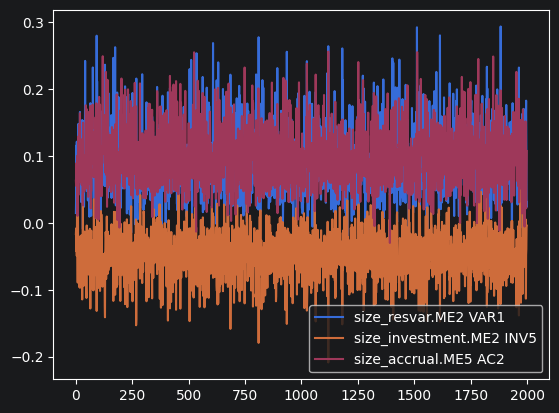

In [17]:
w_fm_plot = w_fm.sample(3, axis=1)
w_fm_plot.plot()
